In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = pd.read_csv('movie_dataset.csv',encoding='latin-1')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (15509, 10)

First 5 rows:


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
missing = df.isnull().sum()

In [7]:
missing_percent = (missing / len(df)) * 100

In [8]:
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_percent})

In [9]:
missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

,Missing,Percent
Duration,8269,53.317429
Rating,7590,48.939326
Votes,7589,48.932878
Actor 3,3144,20.272100
Actor 2,2384,15.371720
Genre,1877,12.102650
Actor 1,1617,10.426204
Year,528,3.404475
Director,525,3.385131


In [10]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [11]:
df = df.dropna(subset=['Rating'])

In [12]:
def extract_year(year_str):
    if pd.isna(year_str):
        return np.nan
    year_str = str(year_str).strip()
    # Remove parentheses and extra spaces
    year_str = year_str.replace('(', '').replace(')', '').strip()
    import re
    match = re.search(r'\b(\d{4})\b', year_str)
    if match:
        return int(match.group(1))
    else:
        return np.nan

df['Year'] = df['Year'].apply(extract_year)

In [13]:
def extract_minutes(dur_str):
    if pd.isna(dur_str):
        return np.nan
    dur_str = str(dur_str).strip()
    if 'min' in dur_str:
        dur_str = dur_str.replace('min', '').strip()
        try:
            return int(dur_str)
        except:
            return np.nan
    else:
        return np.nan

df['Duration'] = df['Duration'].apply(extract_minutes)

In [14]:
def clean_votes(votes_str):
    if pd.isna(votes_str):
        return np.nan
    votes_str = str(votes_str).replace(',', '').strip()
    try:
        return int(votes_str)
    except:
        return np.nan

df['Votes'] = df['Votes'].apply(clean_votes)

In [15]:
def get_first_genre(genre_str):
    if pd.isna(genre_str):
        return 'Unknown'
    genres = genre_str.split(',')
    return genres[0].strip()

df['Main_Genre'] = df['Genre'].apply(get_first_genre)

In [16]:
for col in ['Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = df[col].fillna('Unknown')

In [17]:
df = df.dropna(subset=['Year', 'Duration', 'Votes'])

In [18]:
print(f"\nDataset after cleaning: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset after cleaning: 5851 rows, 11 columns


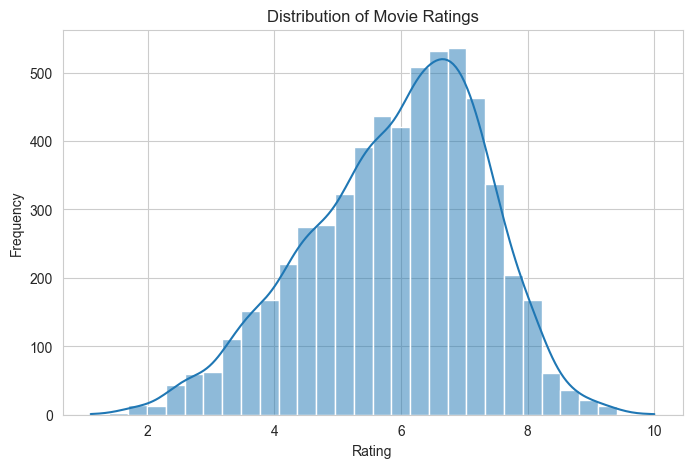

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Rating'], bins=30, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

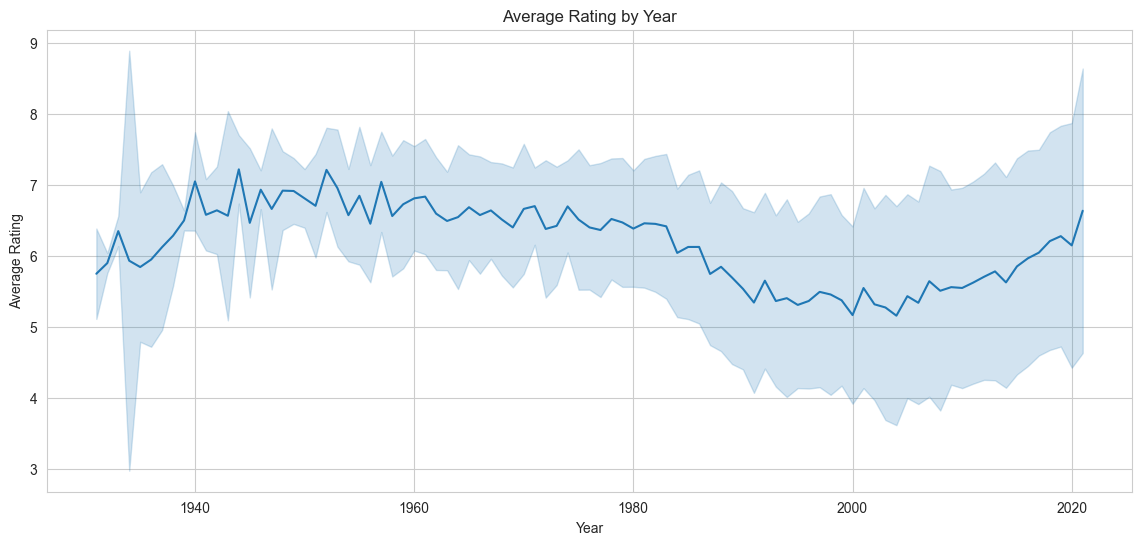

In [20]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='Year', y='Rating', data=df, errorbar='sd', estimator='mean')
plt.title('Average Rating by Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()


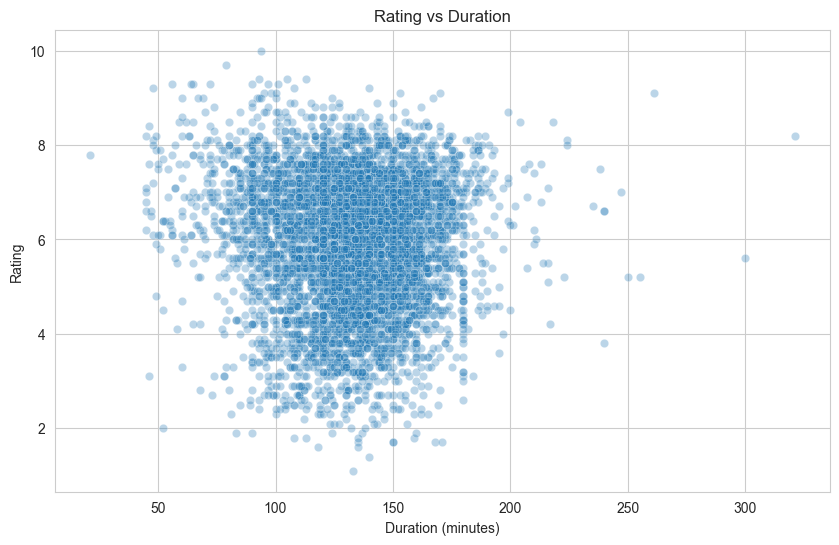

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Duration', y='Rating', data=df, alpha=0.3)
plt.title('Rating vs Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Rating')
plt.show()

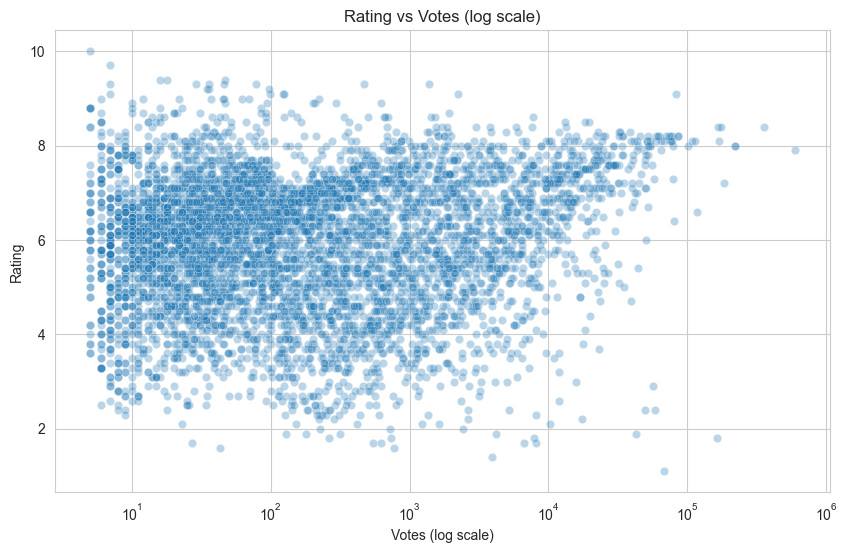

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Votes', y='Rating', data=df, alpha=0.3)
plt.xscale('log')
plt.title('Rating vs Votes (log scale)')
plt.xlabel('Votes (log scale)')
plt.ylabel('Rating')
plt.show()

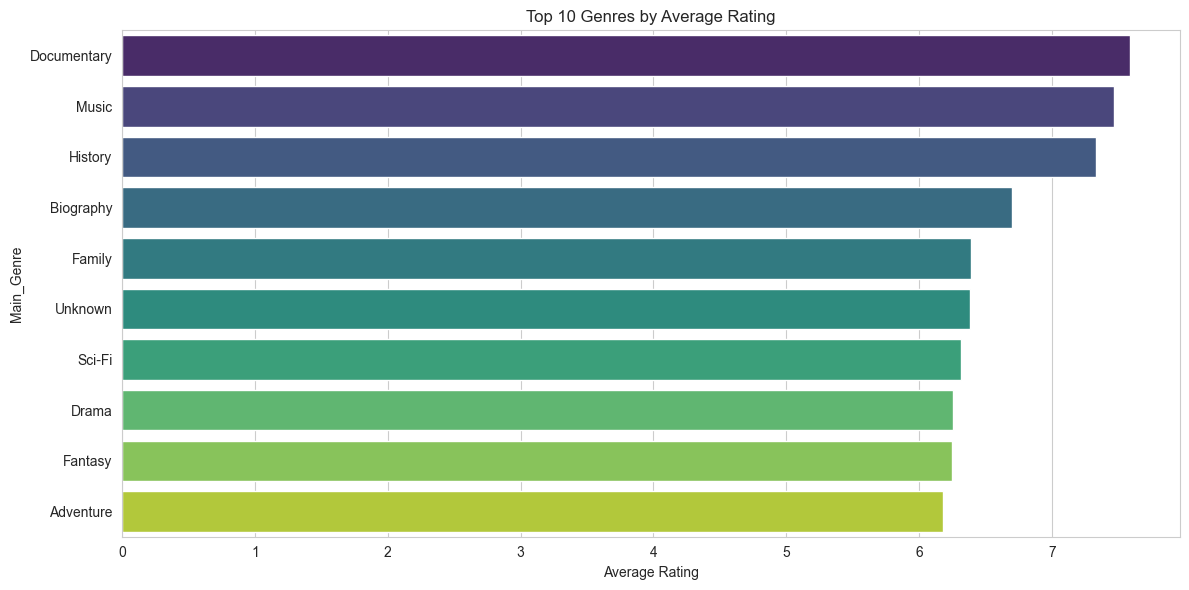

In [23]:
genre_avg = df.groupby('Main_Genre')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))

sns.barplot(
    x=genre_avg.values,
    y=genre_avg.index,
    hue=genre_avg.index,
    palette='viridis',
    legend=False
)
plt.title('Top 10 Genres by Average Rating')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.show()

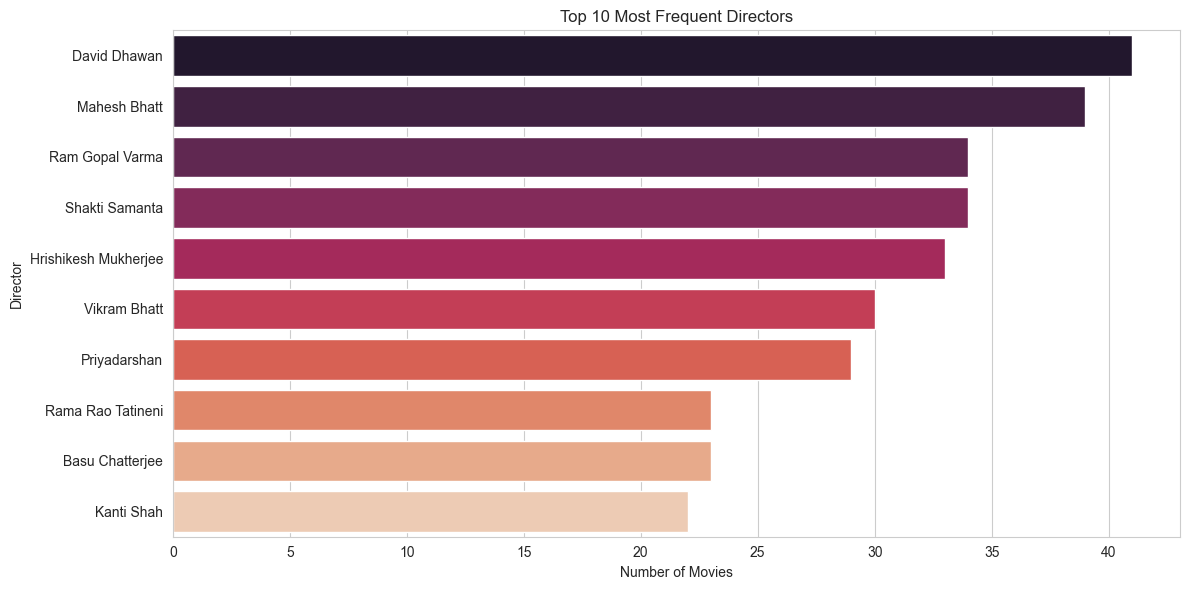

In [24]:
top_directors = df['Director'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    palette='rocket',
    legend=False
)
plt.title('Top 10 Most Frequent Directors')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.show()

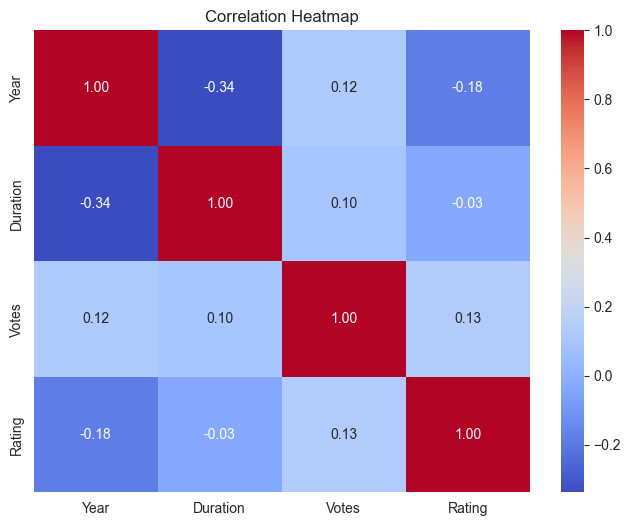

In [25]:
numeric_cols = ['Year', 'Duration', 'Votes', 'Rating']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [26]:
features = ['Year', 'Duration', 'Votes', 'Main_Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
X = df[features]
y = df['Rating']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train

,Year,Duration,Votes,Main_Genre,Director,Actor 1,Actor 2,Actor 3
8400,2014,112.0,611,Adventure,Agneya Singh,Aban Raza,Tom Alter,Raaghavv Chanana
15159,1985,137.0,32,Action,Vinod Dewan,Mithun Chakraborty,Zeenat Aman,Shakti Kapoor
12256,2007,77.0,36,Drama,Khalid Y. Batliwalla,Pratima V. Kulkarni,Meghan Jadhav,Ravi Behl
212,1968,175.0,196,Drama,A. Bhimsingh,Dilip Kumar,Waheeda Rehman,Manoj Kumar
13317,1999,169.0,270,Action,K.S. Ravikumar,Chiranjeevi,Meena,Vijayakumar
...,...,...,...,...,...,...,...,...
9901,1967,158.0,20,Drama,C.V. Sridhar,Ashok Kumar,Mala Sinha,Raaj Kumar
13891,1966,159.0,746,Comedy,Basu Bhattacharya,Raj Kapoor,Waheeda Rehman,Dulari
13954,2016,130.0,71,Action,Satish Kasetty,Meka Srikanth,Nikita Thukral,Ravi Varma
14320,1953,140.0,13,Drama,Lekhraj Bhakri,Shammi Kapoor,Shyama,Ravindra Kapoor


In [29]:
X_test

,Year,Duration,Votes,Main_Genre,Director,Actor 1,Actor 2,Actor 3
3563,1990,130.0,953,Romance,Y. Nageswara Rao,M. Parvez,Aamir Khan,Madhuri Dixit
2023,1981,121.0,30,Adventure,Kashinath,Mithun Chakraborty,Amrish Puri,Sonia Sahni
9526,2018,84.0,15,Documentary,Rob Fruchtman,Unknown,Unknown,Unknown
40,2012,124.0,1811,Drama,Bhushan Patel,Vicky Ahuja,Tia Bajpai,Tarakesh Chauhan
1876,2015,80.0,149,Adventure,Praveen Morchhale,Sonu Chourasia,Ajay Chourey,Farrukh Jaffar
...,...,...,...,...,...,...,...,...
8313,2016,114.0,873,Crime,Vikram Bhatt,Patralekhaa Paul,Tara-Alisha Berry,Gaurav Arora
13908,2000,143.0,560,Musical,A. Muthu,Abhishek Bachchan,Kirti Reddy,Sanjay Suri
14373,2010,122.0,374,Comedy,Kedar Shinde,Tabu,Sharman Joshi,Yuvika Chaudhary
14490,2017,136.0,17774,Drama,Kabir Khan,Salman Khan,Sohail Khan,Om Puri


In [30]:
y_train

8400     5.6
15159    6.0
12256    5.8
212      6.8
13317    6.5
        ... 
9901     6.3
13891    7.9
13954    6.8
14320    7.3
2149     7.1
Name: Rating, Length: 4680, dtype: float64

In [31]:
y_test

3563     5.7
2023     6.3
9526     7.9
40       4.8
1876     5.6
        ... 
8313     4.3
13908    3.0
14373    5.1
14490    3.8
13028    5.6
Name: Rating, Length: 1171, dtype: float64

In [32]:
categorical_cols = ['Main_Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']
encoders = {}
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(X_train[col])
    X_train_enc[col] = le.transform(X_train[col])
   
    mapping = {label: idx for idx, label in enumerate(le.classes_)}
    X_test_enc[col] = X_test[col].map(lambda x: mapping.get(x, -1))
    encoders[col] = le

In [33]:
numeric_cols = ['Year', 'Duration', 'Votes']
X_train_final = X_train_enc[numeric_cols + categorical_cols]
X_test_final = X_test_enc[numeric_cols + categorical_cols]

In [34]:
scaler = StandardScaler()
X_train_final[numeric_cols] = scaler.fit_transform(X_train_final[numeric_cols])
X_test_final[numeric_cols] = scaler.transform(X_test_final[numeric_cols])

In [35]:
print("Training features shape:", X_train_final.shape)
print("Test features shape:", X_test_final.shape)

Training features shape: (4680, 8)
Test features shape: (1171, 8)


In [36]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    predictions[name] = y_pred
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")




Linear Regression:
  RMSE: 1.3607
  MAE:  1.0834
  R²:   0.0048

Random Forest:
  RMSE: 1.1511
  MAE:  0.8693
  R²:   0.2878


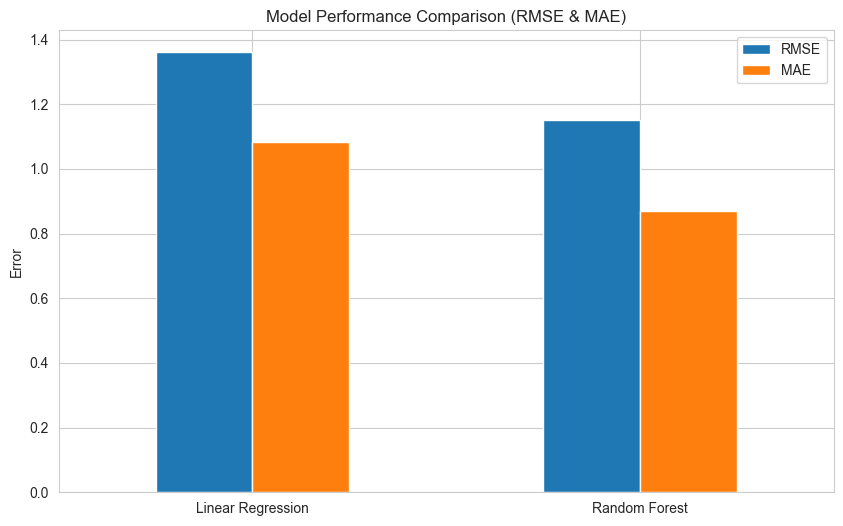

In [37]:
metrics_df = pd.DataFrame(results).T
metrics_df[['RMSE', 'MAE']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison (RMSE & MAE)')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.show()

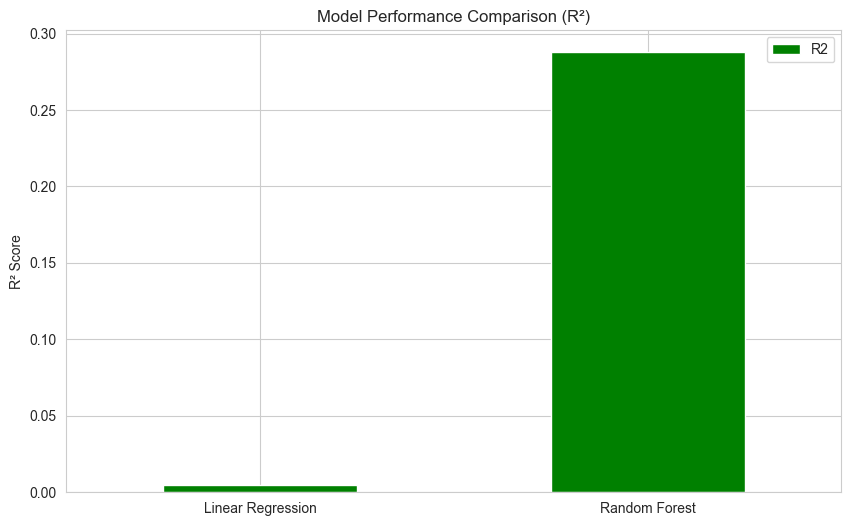

In [38]:
metrics_df[['R2']].plot(kind='bar', figsize=(10, 6), color='green')
plt.title('Model Performance Comparison (R²)')
plt.ylabel('R² Score')
plt.xticks(rotation=0)
plt.show()

In [39]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = numeric_cols + categorical_cols
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

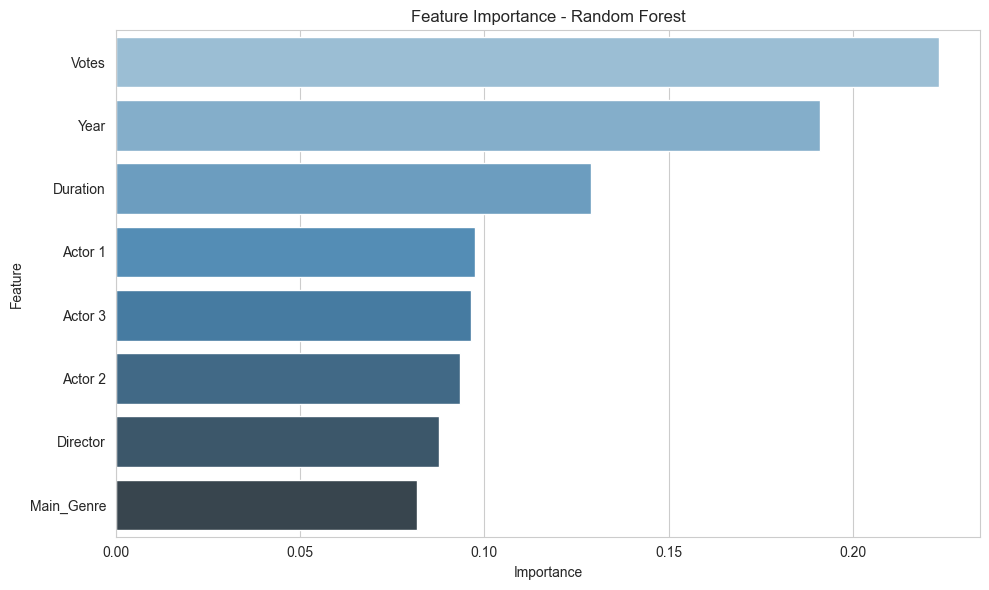

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=feat_imp_df,
    palette='Blues_d',
    legend=False
)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

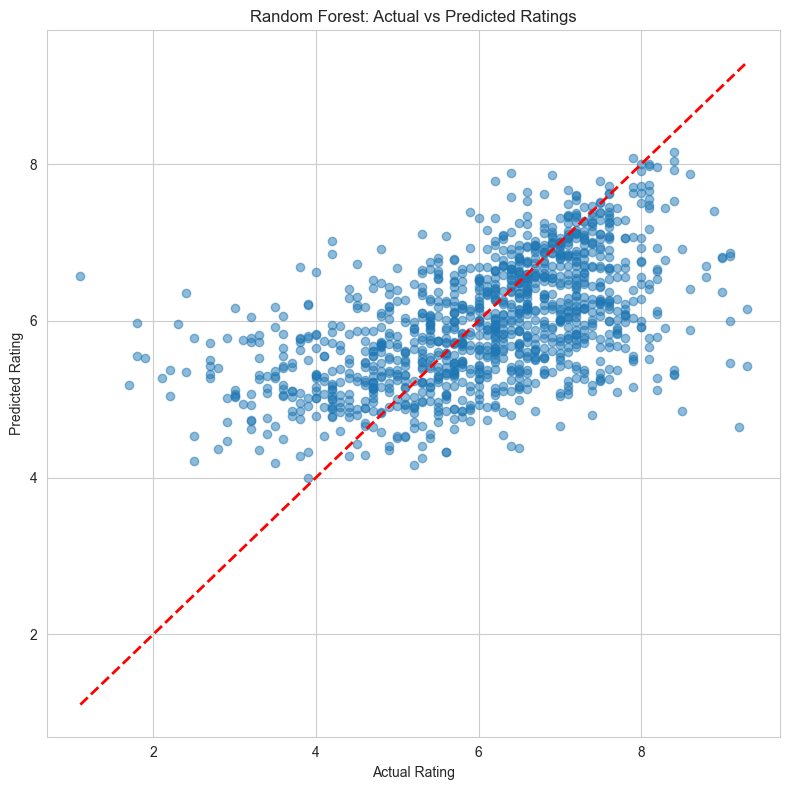

In [41]:
y_pred_rf = predictions['Random Forest']

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Random Forest: Actual vs Predicted Ratings')
plt.tight_layout()
plt.show()

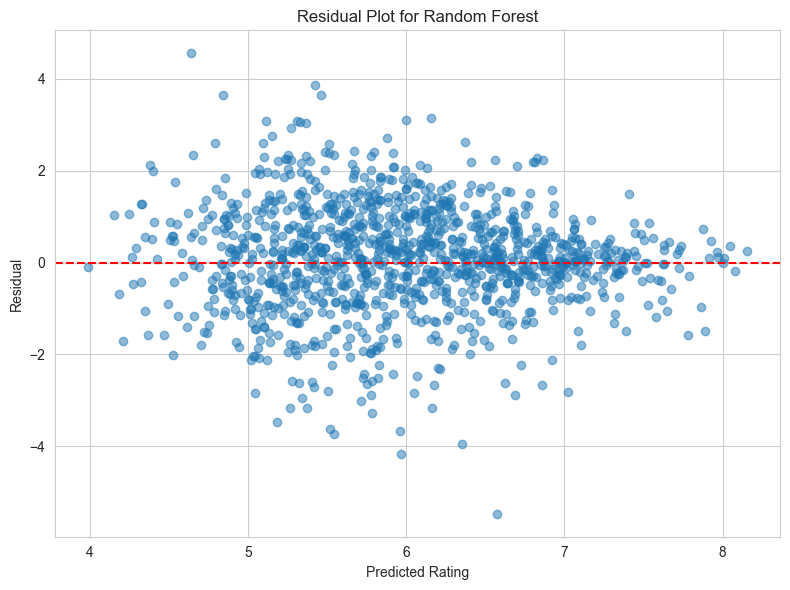

In [42]:
residuals = y_test - y_pred_rf
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Rating')
plt.ylabel('Residual')
plt.title('Residual Plot for Random Forest')
plt.tight_layout()
plt.show()